In [1]:
# Q1(a)
from sklearn.datasets import make_blobs

# Generate dataset
X, y = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.2,
    random_state=0
)

# Print shape to determine number of features
print("Shape of X:", X.shape)

Shape of X: (500, 2)


The generated dataset has a shape of (500, 2), which indicates that each data sample contains 2 features.

In [2]:
# Q1(b)
from sklearn.cluster import KMeans

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=0)
y_pred = kmeans.fit_predict(X)

print("Cluster labels generated.")
print("Predicted cluster labels shape:", y_pred.shape)
print("Cluster centers:\n", kmeans.cluster_centers_)

Cluster labels generated.
Predicted cluster labels shape: (500,)
Cluster centers:
 [[ 2.03969938  0.75456926]
 [ 0.88518002  4.51955751]
 [-1.74916744  2.64717849]
 [-1.26063933  7.86554549]]


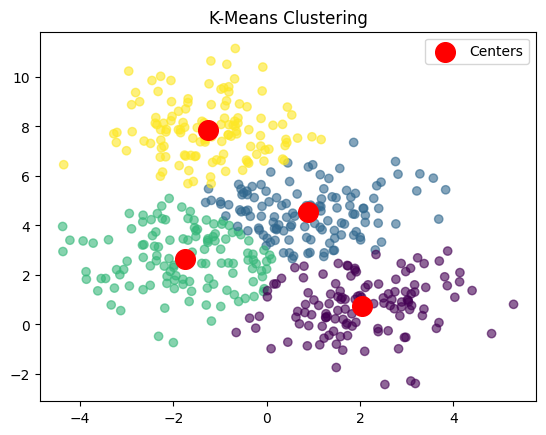

In [3]:
# Q1(c)
import matplotlib.pyplot as plt

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="viridis", alpha=0.6)

# Plot cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c="red",
    s=200,
    label="Centers"
)

plt.title("K-Means Clustering")
plt.legend()
plt.show()

The scatter plot shows that the K-Means algorithm successfully groups the data into four distinct clusters, with each cluster represented by a different color. The red points correspond to the cluster centers obtained from the cluster_centers_ attribute. These cluster centers represent the centroids of the clusters, which are the mean positions of all data points assigned to each cluster.

In [4]:
# Q1(d)
import numpy as np
from scipy.stats import mode
from sklearn.metrics import accuracy_score

# Align cluster labels with true labels
labels = kmeans.labels_
labels_aligned = np.zeros_like(labels)

for i in range(4):
    mask = (labels == i)
    labels_aligned[mask] = mode(y[mask])[0]

# Compute accuracy
accuracy = accuracy_score(y, labels_aligned)

print("Clustering Accuracy:", accuracy)

Clustering Accuracy: 0.886


The predicted cluster labels are first aligned with the true labels to account for possible label permutation in K-Means. After alignment, the clustering accuracy is approximately 0.886. This indicates that most of the data points are correctly clustered, but not all points are perfectly assigned to their true clusters. Therefore, not all points are correctly clustered. This is expected because K-Means is an unsupervised algorithm that minimizes within-cluster variance and does not use true labels during training, which can lead to some misclassifications, especially near cluster boundaries.

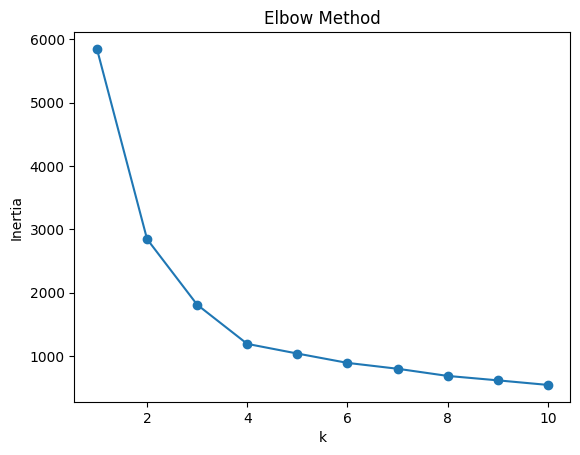

Inertias: [5850.03421112754, 2845.686183825962, 1809.104660146504, 1189.9618065198495, 1037.403219370229, 889.7753734354178, 797.0350706788447, 683.8235881959586, 614.0682271114925, 541.6358964108626]


In [5]:
# Q2(a)
inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# Plot Elbow curve
plt.figure()
plt.plot(k_values, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
print("Inertias:", inertias)

According to the Elbow Method, the optimal number of clusters is approximately k = 4. This is because the inertia decreases rapidly from k = 1 to k = 4, after which the rate of decrease slows down significantly. The point where this change in slope occurs represents the “elbow,” indicating that adding more clusters beyond this point does not provide substantial improvement.

TR:

In [6]:
# Q2(b)
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    
    silhouette_scores[k] = score
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 2, Silhouette Score = 0.4288
k = 3, Silhouette Score = 0.4109
k = 4, Silhouette Score = 0.4431
k = 5, Silhouette Score = 0.4089
k = 6, Silhouette Score = 0.3875
k = 7, Silhouette Score = 0.3423
k = 8, Silhouette Score = 0.3315
k = 9, Silhouette Score = 0.3378
k = 10, Silhouette Score = 0.3470


The silhouette scores for different values of k indicate that the highest score is obtained at k = 4 (approximately 0.4431). Therefore, the optimal number of clusters according to the silhouette method is k = 4, as it provides the best balance between cluster cohesion and separation.

The silhouette score evaluates how similar each data point is to its own cluster compared to other clusters, making it a reliable metric for cluster quality.

The elbow method and silhouette score method do not always produce the same result because they are based on different criteria. The elbow method focuses on minimizing inertia (within-cluster variance), while the silhouette score considers both intra-cluster cohesion and inter-cluster separation. However, in this case, both methods agree and suggest k = 4 as the optimal number of clusters.

In [7]:
# Q3(a)
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X)

print("DBSCAN clustering completed.")
print("Unique DBSCAN labels:", np.unique(db_labels))

DBSCAN clustering completed.
Unique DBSCAN labels: [-1  0  1  2  3  4  5]


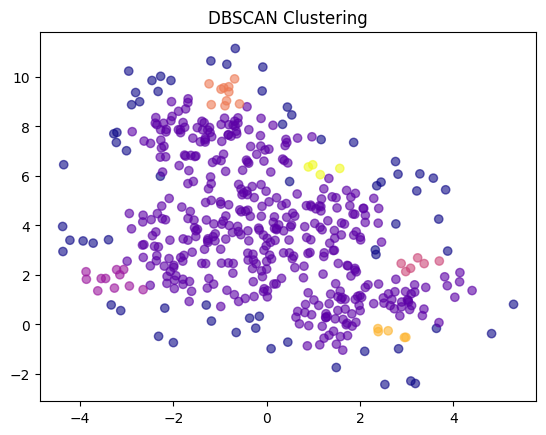

In [8]:
# Q3(b)
# Plot DBSCAN clusters
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=db_labels, cmap="plasma", alpha=0.6)
plt.title("DBSCAN Clustering")
plt.show()

The scatter plot shows the clustering result of the DBSCAN algorithm, where different colors represent different clusters. Unlike K-Means, DBSCAN does not explicitly compute cluster centers.

The label -1 represents noise points, meaning data samples that do not belong to any cluster because they are located in low-density regions.

DBSCAN can generate meaningful clusters when the data contains regions of varying density and non-spherical shapes. In this example, DBSCAN identifies dense regions and separates noise points effectively. However, depending on the chosen parameters (eps and min_samples), it may produce many small clusters or classify a large portion of the data as noise.

DBSCAN performs better than K-Means when the data has irregular (non-spherical) shapes, varying densities, or contains outliers. In contrast, K-Means performs better when clusters are well-separated and roughly spherical.

In [9]:
# Q4(a)
# Create partially labeled dataset
y_partial = y.copy()

# Keep only first 10% labeled
n_labeled = int(0.1 * len(y))
y_partial[n_labeled:] = -1

print("Partial labeling completed.")
print("First 20 labels in y_partial:", y_partial[:20])

Partial labeling completed.
First 20 labels in y_partial: [1 1 0 0 1 2 2 0 0 3 2 1 2 3 0 0 1 0 3 0]


In [10]:
# Q4(b)
# Label Propagation (full overwrite)

clusters = KMeans(n_clusters=4, random_state=0).fit_predict(X)
labels_propagated = np.copy(y_partial)

for i in range(4):
    mask = (clusters == i)
    
    # Check if cluster contains labeled samples
    if np.any(y_partial[mask] != -1):
        most_common = mode(y_partial[mask][y_partial[mask] != -1])[0]
        labels_propagated[mask] = most_common

print("Label propagation (full) completed.")
print("First 20 propagated labels:", labels_propagated[:20])

Label propagation (full) completed.
First 20 propagated labels: [1 1 0 0 0 2 0 0 1 3 2 1 2 3 0 0 1 0 3 0]


In [11]:
# Q4(c)
from sklearn.linear_model import LogisticRegression

# Train classifier
model = LogisticRegression(max_iter=10000)
model.fit(X, labels_propagated)

# Predict
y_pred = model.predict(X)

# Evaluate
accuracy = accuracy_score(y, y_pred)
print("Accuracy after label propagation:", accuracy)

Accuracy after label propagation: 0.886


A logistic regression classifier was trained using the propagated labels as the target values, with the maximum number of iterations set to 10000. The model was then used to predict labels for all data samples, and the prediction accuracy was computed by comparing the predicted labels with the true labels.

The resulting accuracy is approximately 0.886, which indicates that the model performs reasonably well even though it was trained using partially labeled data that was completed through label propagation. This demonstrates that label propagation can effectively improve the quality of labels and enable a classifier to achieve good performance with limited initial labeled data.

In [12]:
# Q4(d)
# Label Propagation (only unlabeled)

labels_propagated = np.copy(y_partial)

for i in range(4):
    mask = (clusters == i)
    
    if np.any(y_partial[mask] != -1):
        most_common = mode(y_partial[mask][y_partial[mask] != -1])[0]
        
        # Only update unlabeled samples
        unlabeled_mask = mask & (y_partial == -1)
        labels_propagated[unlabeled_mask] = most_common

print("Label propagation (unlabeled only) completed.")

Label propagation (unlabeled only) completed.


In [13]:
# Q4(d) continuation - retrain model
model = LogisticRegression(max_iter=10000)
model.fit(X, labels_propagated)

y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)

print("Accuracy (unlabeled only propagation):", accuracy)

Accuracy (unlabeled only propagation): 0.886


In this step, label propagation is applied by updating only the unlabeled data points (i.e., those with label -1 in y_partial). For each cluster, the most frequent label among the labeled samples is identified and assigned only to the unlabeled samples within that cluster, while the original labeled data remains unchanged.

After training a logistic regression classifier using the propagated labels, the prediction accuracy is approximately 0.886. This result is very similar to the accuracy obtained in part (c), where all labels (including already labeled ones) were updated.

This indicates that restricting label propagation to only unlabeled samples can preserve the original label information without significantly affecting the overall performance. Therefore, this approach is often preferred as it avoids overwriting potentially correct existing labels while still benefiting from semi-supervised learning.

**Question 4(e)**

In our implementation, label propagation achieved an accuracy of approximately 0.886, which indicates that the method works reasonably well for this dataset. However, label propagation using clustering is expected to fail when the clusters do not align well with the true class structure.

For example, if a cluster contains samples from multiple classes, propagating the most frequent label within that cluster will assign incorrect labels to some data points. This issue becomes more critical when cluster boundaries overlap or when the clustering algorithm (e.g., K-Means) does not accurately capture the true distribution of the data.

Additionally, if the initial labeled data (in our case only 10%) is not representative of all classes or is unevenly distributed across clusters, the propagated labels may be biased and lead to incorrect predictions.

Therefore, although label propagation performed well in this experiment, it may fail in cases where clusters are not pure, the data has complex structures, or the initial labeled samples are insufficient or unbalanced.

In [14]:
# Q5(a)
from sklearn.datasets import make_moons

# Generate moons dataset
X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=0
)

print("Moons dataset generated.")

Moons dataset generated.


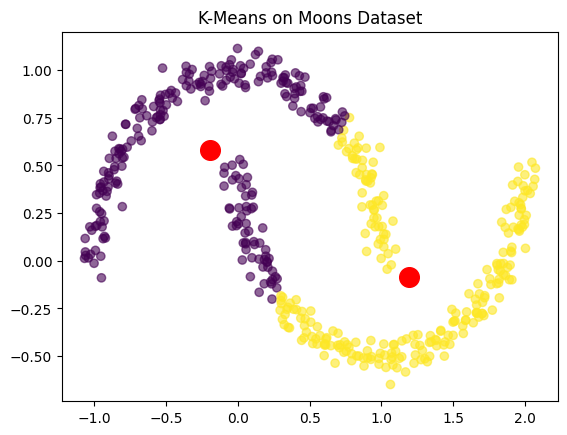

In [15]:
# Q5(b)
# K-Means on moons
kmeans_moons = KMeans(n_clusters=2, random_state=0)
labels_kmeans = kmeans_moons.fit_predict(X_moons)

# Plot
plt.figure()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans, cmap="viridis", alpha=0.6)

plt.scatter(
    kmeans_moons.cluster_centers_[:, 0],
    kmeans_moons.cluster_centers_[:, 1],
    c="red",
    s=200
)

plt.title("K-Means on Moons Dataset")
plt.show()

The scatter plot shows that the K-Means algorithm fails to generate meaningful clusters for the moons dataset. Although the dataset contains two distinct classes, K-Means incorrectly partitions the data by drawing a linear boundary between clusters.

This happens because K-Means assumes that clusters are spherical and separable based on distance to cluster centroids. However, the moons dataset has a non-linear, curved structure, where the two classes form interleaving half-moon shapes. As a result, K-Means is unable to capture the true underlying structure of the data and produces incorrect cluster assignments.

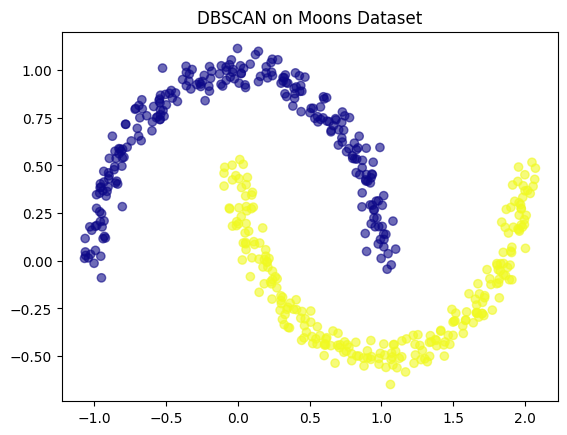

In [16]:
# Q5(c)
# DBSCAN on moons
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan = dbscan_moons.fit_predict(X_moons)

# Plot
plt.figure()
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_dbscan, cmap="plasma", alpha=0.6)
plt.title("DBSCAN on Moons Dataset")
plt.show()

The scatter plot shows that the DBSCAN algorithm successfully generates meaningful clusters for the moons dataset. The two interleaving half-moon shapes are correctly identified as separate clusters, which indicates that DBSCAN effectively captures the underlying structure of the data.

Unlike K-Means, DBSCAN does not assume spherical clusters and instead groups data based on density. This allows it to detect clusters with arbitrary shapes, such as the curved structure present in the moons dataset. As a result, DBSCAN is able to correctly separate the two classes and produce accurate clustering results for this dataset.